# Data Analysis

## Importing the libraries

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Dataset
### Showing the Data
Show the top columns of the dataset, which includes the data of each cancer tumour.

In [9]:
real1 = pd.read_csv('./data/real1/snv-parse-real1-labeled.txt', sep='\t', dtype={'Chr': str})
real1['Chr'] = real1['Chr'].astype('str') 
len(real1)
real2 = pd.read_csv('./data/real2_part1/snv-parse-real2_part1-labeled.txt', sep='\t', dtype={'Chr': str})
real2['Chr'] = real2['Chr'].astype('str') 
len(real2)
syn1 = pd.read_csv('./data/syn1/snv-parse-syn1-labeled.txt', sep='\t', dtype={'Chr': str})
syn1['Chr'] = syn1['Chr'].astype('str') 
len(syn1)
syn2 = pd.read_csv('./data/syn2/snv-parse-syn2-labeled.txt', sep='\t', dtype={'Chr': str})
syn2['Chr'] = syn2['Chr'].astype('str') 
len(syn2)
syn3 = pd.read_csv('./data/syn3/snv-parse-syn3-labeled.txt', sep='\t', dtype={'Chr': str})
syn3['Chr'] = syn3['Chr'].astype('str') 
len(syn3)
syn4 = pd.read_csv('./data/syn4/snv-parse-syn4-labeled.txt', sep='\t', dtype={'Chr': str})
syn4['Chr'] = syn4['Chr'].astype('str') 
len(syn4)
syn5 = pd.read_csv('./data/syn5/snv-parse-syn5-labeled.txt', sep='\t', dtype={'Chr': str})
syn5['Chr'] = syn5['Chr'].astype('str') 
len(syn5)

df = pd.concat([real1, real2, syn1, syn2, syn3, syn4, syn5], ignore_index=True)
df.shape

(306221, 19)

Use the method 'describe' to see the distribution of the numerical values and statistics data. Good to look at min/max values to see any outliers that must put attention on, etc.

In [10]:
df.describe()

,START_POS_REF,END_POS_REF,m2_MQ,f_MQMR,vs_SSC,vs_SPV,vd_SSF,vd_MSI
count,3.062210e+05,3.062210e+05,125584.000000,109252.000000,238759.000000,238759.000000,161303.000000,161303.000000
mean,7.331304e+07,7.331304e+07,57.496172,54.963817,17.264593,0.117079,0.086558,3.084829
std,5.726451e+07,5.726451e+07,5.267026,12.546463,18.236466,0.164220,0.179495,3.816062
min,3.000000e+00,3.000000e+00,7.860000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.637710e+07,2.637710e+07,57.990000,58.714300,7.000000,0.006809,0.000340,1.000000
50%,6.169157e+07,6.169157e+07,60.000000,60.000000,13.000000,0.045960,0.011460,2.000000
75%,1.109767e+08,1.109767e+08,60.000000,60.000000,21.000000,0.179310,0.089290,3.000000
max,2.492405e+08,2.492405e+08,63.640000,70.000000,255.000000,1.000000,1.000000,56.000000


The following method allows us to also see the number of null values of each column.

We see that m2_MQ and f_MQMR have simimlar missing values (which makes sense beacuse both tell about the mapping quality of the genome), then vs_SSC/SPV have also similar Nan values because both are related to varScan, and finally vd_SSF/MSI have similar NAN values because both are related to varDict. 

Possible reasons: 
- If there is high error in a read or the coverage was too low, then maybe outputs were not released.
- It could be related to how algorithms work and that in specific cases they decide to not output a given value.
- Maybe the researcher deleted those rows when preprocessing?
- Maybe if an algorithm didn't stored any SNV position, then skip the data. Maybe they provide metrics at variant side.
- Maybe all of the above.

In [11]:
df.isnull().sum()

Chr                      0
START_POS_REF            0
END_POS_REF              0
REF                      0
ALT                      0
REF_MFVdVs               0
ALT_MFVdVs               0
Sample_Name              0
FILTER_Mutect2           0
FILTER_Freebayes         0
FILTER_Vardict           0
FILTER_Varscan           0
m2_MQ               180637
f_MQMR              196969
vs_SSC               67462
vs_SPV               67462
vd_SSF              144918
vd_MSI              144918
True_SNV                 0
dtype: int64

### Analysis

Print the columns that compose the dataset

In [7]:
columns = df.columns.tolist()
columns

['Chr',
 'START_POS_REF',
 'END_POS_REF',
 'REF',
 'ALT',
 'REF_MFVdVs',
 'ALT_MFVdVs',
 'Sample_Name',
 'FILTER_Mutect2',
 'FILTER_Freebayes',
 'FILTER_Vardict',
 'FILTER_Varscan',
 'm2_MQ',
 'f_MQMR',
 'vs_SSC',
 'vs_SPV',
 'vd_SSF',
 'vd_MSI']

To be able to see the rows that have null values, we can use the following method

In [9]:
df[df.isnull().any(axis=1)]

,Chr,START_POS_REF,END_POS_REF,REF,ALT,REF_MFVdVs,ALT_MFVdVs,Sample_Name,FILTER_Mutect2,FILTER_Freebayes,FILTER_Vardict,FILTER_Varscan,m2_MQ,f_MQMR,vs_SSC,vs_SPV,vd_SSF,vd_MSI
0,1,10303,10303,C,T,NA/NA/NA/C/,NA/NA/NA/T/,icgc_cll_tumour,False,False,False,True,NaN,NaN,5.0,0.277780,NaN,NaN
1,1,16949,16949,A,C,A/NA/NA/A/,C/NA/NA/C/,icgc_cll_tumour,False,False,False,True,22.92,NaN,20.0,0.008314,NaN,NaN
2,1,20628,20628,A,G,NA/A/A/A/,NA/G/G/G/,icgc_cll_tumour,False,False,True,False,NaN,NaN,8.0,0.139060,0.00469,2.0
3,1,30489,30489,G,A,NA/NA/NA/G/,NA/NA/NA/A/,icgc_cll_tumour,False,False,False,True,NaN,NaN,13.0,0.046735,NaN,NaN
4,1,30808,30808,A,G,NA/NA/NA/A/,NA/NA/NA/G/,icgc_cll_tumour,False,False,False,True,NaN,NaN,19.0,0.012309,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3535,9,139138662,139138662,G,A,G/NA/NA/NA/,A/NA/NA/NA/,icgc_cll_tumour,True,False,False,False,60.00,NaN,NaN,NaN,NaN,NaN
3536,9,140378948,140378948,G,A,G/NA/NA/NA/,A/NA/NA/NA/,icgc_cll_tumour,True,False,False,False,60.00,NaN,NaN,NaN,NaN,NaN
3537,9,141046294,141046294,C,T,C/NA/NA/NA/,T/NA/NA/NA/,icgc_cll_tumour,True,False,False,False,58.97,NaN,NaN,NaN,NaN,NaN
3538,9,141062718,141062718,T,C,T/NA/NA/NA/,C/NA/NA/NA/,icgc_cll_tumour,True,False,False,False,58.84,NaN,NaN,NaN,NaN,NaN


## Understanding the data

The following code will be used to understand what each columns mean and what do their value represent

In [8]:
columns = df.columns.tolist()
print(columns)
df[df.isnull().any(axis=1)]
df.head()

['Chr', 'START_POS_REF', 'END_POS_REF', 'REF', 'ALT', 'REF_MFVdVs', 'ALT_MFVdVs', 'Sample_Name', 'FILTER_Mutect2', 'FILTER_Freebayes', 'FILTER_Vardict', 'FILTER_Varscan', 'm2_MQ', 'f_MQMR', 'vs_SSC', 'vs_SPV', 'vd_SSF', 'vd_MSI']


,Chr,START_POS_REF,END_POS_REF,REF,ALT,REF_MFVdVs,ALT_MFVdVs,Sample_Name,FILTER_Mutect2,FILTER_Freebayes,FILTER_Vardict,FILTER_Varscan,m2_MQ,f_MQMR,vs_SSC,vs_SPV,vd_SSF,vd_MSI
0,1,13110,13110,G,A,G/NA/G/G/,A/NA/A/A/,icgc_cll-T,True,False,False,False,41.91,NaN,2.0,0.522430,0.23427,2.0
1,1,15015,15015,G,C,G/NA/NA/G/,C/NA/NA/C/,icgc_cll-T,True,False,False,False,43.42,NaN,5.0,0.302390,NaN,NaN
2,1,16949,16949,A,C,NA/NA/NA/A/,NA/NA/NA/C/,icgc_cll-T,False,False,False,True,NaN,NaN,16.0,0.023282,NaN,NaN
3,1,40552,40552,T,C,NA/NA/NA/T/,NA/NA/NA/C/,icgc_cll-T,False,False,False,True,NaN,NaN,26.0,0.002231,NaN,NaN
4,1,46907,46907,T,C,NA/NA/NA/T/,NA/NA/NA/C/,icgc_cll-T,False,False,False,True,NaN,NaN,17.0,0.017670,NaN,NaN


## Understanding the columns

Breakdown of each column

---

## **1. Genomic Position Information**
| Column | Description | Example Value |
|--------|------------|--------------|
| **Chr** | Chromosome number where the SNV is located. | `1` |
| **START_POS_REF** | Start position of the SNV in the reference genome. | `13110` |
| **END_POS_REF** | End position of the SNV in the reference genome (same as `START_POS_REF` for SNVs because an SNV is a single nucleotide that was modified). | `13110` |

- **Format:** Integer (`1, 2, ..., 22, X, Y` for chromosomes)
- **Purpose:** Identifies where in the genome this SNV occurs.

---

## **2. Variant Information**
| Column | Description | Example Value |
|--------|------------|--------------|
| **REF** | Reference nucleotide (what is expected in a normal genome). | `G` |
| **ALT** | Alternate nucleotide (mutation found in the tumor sample). | `A` |

- **Format:** Single-character DNA base (`A, T, C, G`)
- **Purpose:** Shows how the sequence has changed in cancer cells.

---

## **3. Allele Information Across Algorithms**
| Column | Description | Example Value |
|--------|------------|--------------|
| **REF_MFVdVs** | Reference allele calls from all four algorithms: MuTect2 (M), FreeBayes (F), VarDict (Vd), and VarScan (Vs). | `G/NA/G/G/` |
| **ALT_MFVdVs** | Alternate allele calls from all four algorithms: MuTect2 (M), FreeBayes (F), VarDict (Vd), and VarScan (Vs). | `A/NA/A/A/` |

In the example above, it is telling us that MuTect2, VarDict, and VarScan expected the reference nucleotie (what is expected in normal genome) to be 'G', but the alterate allele was 'A', meaning it is a SNV. On the other hand, FreeBayes didn't disagreed that a mutation exists.

- **Format:** Slash-separated (`M/F/Vd/Vs/`), `NA` means the algorithm didn't detect a variant at this position.
- **Purpose:** Shows how each SNV caller interpreted the mutation.

---

## **4. Sample Information**
| Column | Description | Example Value |
|--------|------------|--------------|
| **Sample_Name** | The tumor sample ID. | `icgc_cll-T` |

- **Format:** String (sample name)
- **Purpose:** Identifies which tumor sample this variant belongs to.

---

## **5. Variant Detection by Each Algorithm**
| Column | Description | Example Value |
|--------|------------|--------------|
| **FILTER_Mutect2** | `TRUE` if MuTect2 passed the variant as significant, `FALSE` otherwise. | `TRUE` |
| **FILTER_Freebayes** | `TRUE` if FreeBayes passed the variant, `FALSE` otherwise. | `FALSE` |
| **FILTER_Vardict** | `TRUE` if VarDict passed the variant, `FALSE` otherwise. | `FALSE` |
| **FILTER_Varscan** | `TRUE` if VarScan passed the variant, `FALSE` otherwise. | `FALSE` |

- **Format:** Boolean (`TRUE` or `FALSE`)
- **Purpose:** Indicates whether each algorithm considers the SNV a real mutation.

---

## **6. Variant-Specific Features (Algorithm-Specific Quality Scores)**
| Column | Description | Example Value |
|--------|------------|--------------|
| **m2_MQ** | Mapping quality from **MuTect2** (how confidently the read aligns to the genome). | `41.91` |
| **f_MQMR** | Mapping quality from **FreeBayes**. | `NA` |
| **vs_SSC** | Strand bias from **VarScan** (how evenly reads support the mutation in both DNA strands). | `2` |
| **vs_SPV** | Statistical p-value from **VarScan** (significance of the mutation). | `0.52243` |
| **vd_SSF** | Somatic status score from **VarDict**. | `0.23427` |
| **vd_MSI** | Microsatellite instability (MSI) from **VarDict**. | `2` |

- **Format:** Float or `NA` (if the algorithm didn't calculate it).
- **Purpose:** Algorithm-specific quality metrics for filtering out false positives.

---

## **Summary**
- **Columns 1-3** → Where the variant is in the genome.
- **Columns 4-5** → What the mutation is.
- **Columns 6-7** → How each algorithm sees the reference and alternate alleles.
- **Column 8** → Which tumor sample the variant belongs to.
- **Columns 9-12** → Whether each algorithm validated this SNV.
- **Columns 13-18** → Algorithm-specific scores for quality assessment.

## Results
### Showing and Understanding the data
Show the top columns of the dataset in the '.bed' represent the true somatic SNVs

In [19]:
df = pd.read_csv('./real1/real1_truth.bed', sep='\t', header=None)
df

,0,1,2
0,1,2180985,2180985
1,1,5035185,5035185
2,1,8881322,8881322
3,1,8929624,8929624
4,1,9196716,9196716
...,...,...,...
1314,X,142275497,142275497
1315,X,144737796,144737796
1316,Y,6407994,6407994
1317,Y,15154839,15154839


Each BED file contains **three columns**, and each row in a BED file represents a **confirmed somatic SNV**.

| Column  | Description                                | Example  |
|---------|--------------------------------------------|---------|
| **Chr** | Chromosome number                         | `1`     |
| **Start** | Start position of the SNV               | `13110` |
| **End** | End position of the SNV *(same as Start for SNVs)* | `13110` |

## Data analysis
Here we anayls graphically all the data. 

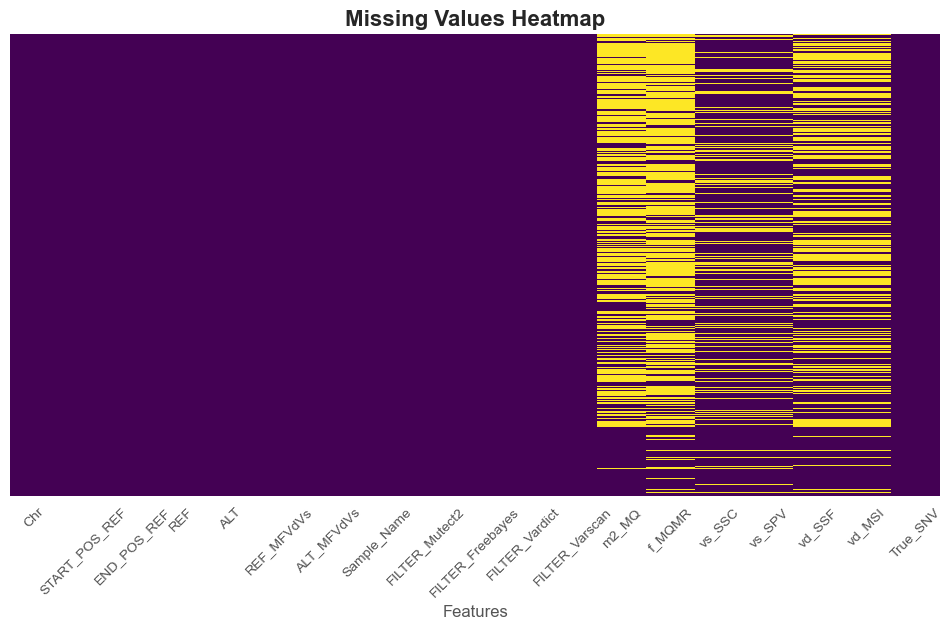

C:\Users\jAlej\AppData\Local\Temp\ipykernel_1084\2445652965.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Algorithm", y="SNV Count", data=snv_df, palette="Blues_d")


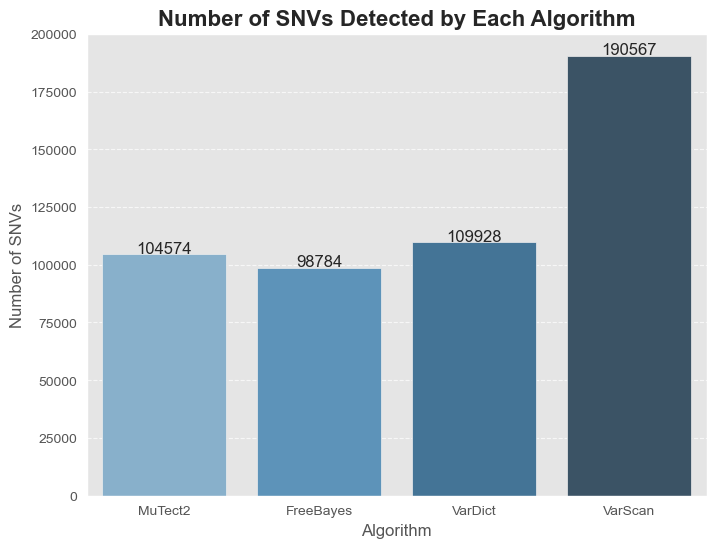

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create DataFrame (assuming 'df' is already defined)
df = pd.concat([real1, real2, syn1, syn2, syn3, syn4, syn5], ignore_index=True)

# Set up a professional-style figure
plt.style.use("ggplot")

# ---- HEATMAP OF MISSING VALUES ----
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cmap="viridis", cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap", fontsize=16, fontweight="bold")
plt.xlabel("Features", fontsize=12)
plt.xticks(rotation=45)
plt.savefig('./graphs/heatmap.png')
plt.show()

# ---- BAR CHART: SNVs DETECTED BY EACH ALGORITHM ----
# Count the number of times each algorithm detected an SNV
snv_counts = {
    "MuTect2": df["FILTER_Mutect2"].sum(),
    "FreeBayes": df["FILTER_Freebayes"].sum(),
    "VarDict": df["FILTER_Vardict"].sum(),
    "VarScan": df["FILTER_Varscan"].sum()
}

# Convert to DataFrame for plotting
snv_df = pd.DataFrame(list(snv_counts.items()), columns=["Algorithm", "SNV Count"])

# Create bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x="Algorithm", y="SNV Count", data=snv_df, palette="Blues_d")
plt.title("Number of SNVs Detected by Each Algorithm", fontsize=16, fontweight="bold")
plt.xlabel("Algorithm", fontsize=12)
plt.ylabel("Number of SNVs", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show values on bars
for index, value in enumerate(snv_df["SNV Count"]):
    plt.text(index, value + 500, str(value), ha="center", fontsize=12)

plt.savefig('./graphs/snvs.png')
plt.show()

<Figure size 800x600 with 0 Axes>

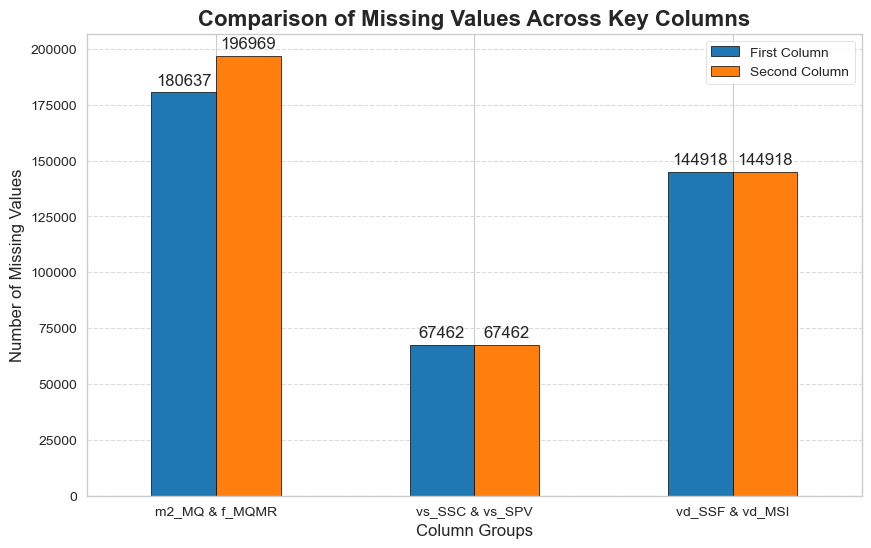

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define missing values counts (from your dataset)
missing_counts = {
    "m2_MQ & f_MQMR": [180637, 196969],
    "vs_SSC & vs_SPV": [67462, 67462],
    "vd_SSF & vd_MSI": [144918, 144918]
}

# Convert to DataFrame for plotting
df_missing = pd.DataFrame(missing_counts, index=["Column 1", "Column 2"])

# Set figure size and style
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid")

# Create a grouped bar chart
df_missing.T.plot(kind="bar", figsize=(10, 6), color=["#1f77b4", "#ff7f0e"], edgecolor="black")

# Customize the plot
plt.title("Comparison of Missing Values Across Key Columns", fontsize=16, fontweight="bold")
plt.xlabel("Column Groups", fontsize=12)
plt.ylabel("Number of Missing Values", fontsize=12)
plt.xticks(rotation=0)
plt.legend(["First Column", "Second Column"], loc="upper right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show values on bars
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', fontsize=12, padding=3)

plt.savefig('./graphs/comparison.png')
plt.show()